In [1]:
import sys
import os
import jax
import jax.numpy as np
import jax.tree as jtu
import jax.random as jr
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Basic jax import
jax.config.update("jax_enable_x64", True)


# # Check if running on remote, and set directory to where notebook is run
# if jax.devices()[0].platform == "gpu":
#     os.chdir("code/amigo_project/notebooks/calibration")

# Add parent directories
paths = [os.path.abspath(os.path.join(os.getcwd(), path)) for path in ['..', "../.."]]
for path in paths:
    if path not in sys.path:
        sys.path.insert(0, path)
        
# Plotting set up
%matplotlib inline
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 120

inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]
inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)


def merge_cbar(ax):
    return make_axes_locatable(ax).append_axes("right", size="5%", pad=0.0)

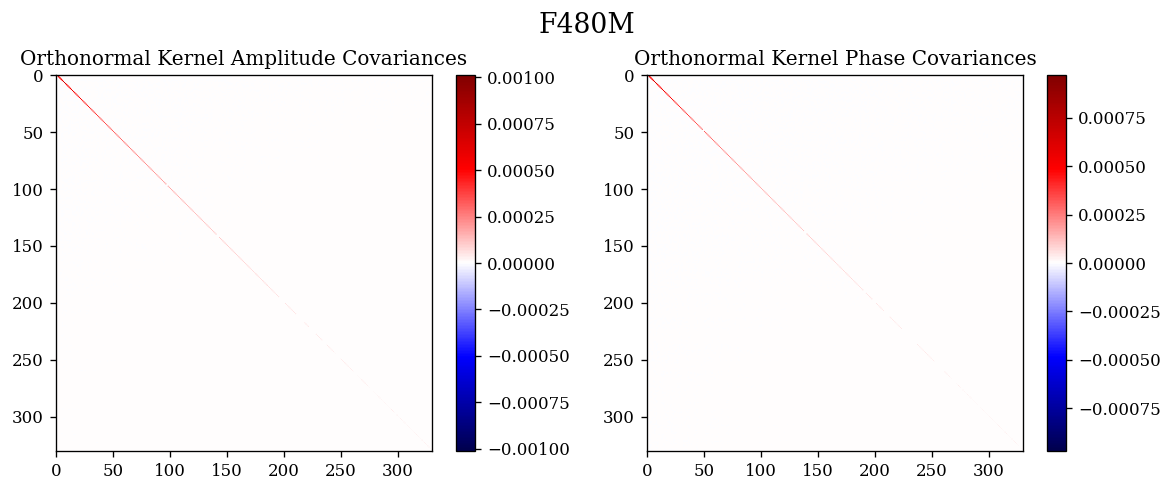

In [2]:
filters = ["F480M"]

cal_vis_outputs = {}
for filt in filters:
    cal_vis = np.load(
        f"/media/morgana1/snert/max/data/amigo_files/outputs/WR137/calIBRATED.npy",
        allow_pickle=True,
    ).item()

    vis = cal_vis["K_vis"]
    phi = cal_vis["K_phi"]
    vis_cov = cal_vis["K_vis_cov"]
    phi_cov = cal_vis["K_phi_cov"]

    vis_vals, vis_vecs = np.linalg.eig(vis_cov)
    phi_vals, phi_vecs = np.linalg.eig(phi_cov)

    # print(vis_vals)
    # print(vis_vecs)
    # plt.imshow(vis_vecs.imag)
    # plt.colorbar()
    # plt.show()

    vis_vals, vis_vecs = vis_vals.real, vis_vecs.real.T
    phi_vals, phi_vecs = phi_vals.real, phi_vecs.real.T

    new_vis_cov = np.dot(vis_vecs, np.dot(vis_cov, np.linalg.inv(vis_vecs)))
    new_phi_cov = np.dot(phi_vecs, np.dot(phi_cov, np.linalg.inv(phi_vecs)))

    new_vis = np.dot(vis_vecs, vis)
    new_phi = np.dot(phi_vecs, phi)

    cal_vis["vis"] = new_vis
    cal_vis["phi"] = new_phi
    cal_vis["vis_cov"] = new_vis_cov
    cal_vis["phi_cov"] = new_phi_cov
    cal_vis["K_vis_proj"] = vis_vecs
    cal_vis["K_phi_proj"] = phi_vecs

    cal_vis_outputs[filt] = cal_vis

    plt.figure(figsize=(10, 4))
    plt.suptitle(filt, fontsize=16)

    v = np.nanmax(np.abs(new_vis_cov))
    plt.subplot(1, 2, 1)
    plt.title("Orthonormal Kernel Amplitude Covariances")
    plt.imshow(new_vis_cov, seismic, vmin=-v, vmax=v, origin="upper")
    plt.colorbar()

    v = np.nanmax(np.abs(new_phi_cov))
    plt.subplot(1, 2, 2)
    plt.title("Orthonormal Kernel Phase Covariances")
    plt.imshow(new_phi_cov, seismic, vmin=-v, vmax=v, origin="upper")
    plt.colorbar()

    plt.tight_layout()
    plt.show()

In [3]:
import equinox as eqx
import zodiax as zdx


class AmigoOIData(zdx.Base):
    # Coordinates
    u: np.ndarray
    v: np.ndarray
    wavel: np.ndarray
    parang: np.ndarray

    # Latent Kernel Visibilities
    vis: np.ndarray
    d_vis: np.ndarray

    # Latent Kernel Phases
    phi: np.ndarray
    d_phi: np.ndarray

    # Latent space projection matrices
    vis_mat: np.ndarray  # Latent -> Pixel
    phi_mat: np.ndarray  # Latent -> Pixel
    vis_mat_inv: np.ndarray  # Pixel -> Latent
    phi_mat_inv: np.ndarray  # Pixel -> Latent

    # Kernel projection matrices
    K_vis_mat: np.ndarray  # Latent -> Null
    K_phi_mat: np.ndarray  # Latent -> Null
    K_vis_mat_inv: np.ndarray  # Null -> Latent
    K_phi_mat_inv: np.ndarray  # Null -> Latent

    # Orthonormal Kernel projection matrices
    K_vis_proj: np.ndarray  # Kernel -> Orthonormal
    K_phi_proj: np.ndarray  # Kernel -> Orthonormal
    K_vis_proj_inv: np.ndarray  # Orthonormal -> Kernel
    K_phi_proj_inv: np.ndarray  # Orthonormal -> Kernel

    def __init__(self, oi_data):
        """
        Default should have vis, phi as their _latent_ values
        """
        self.u = -np.array(oi_data["u"], dtype=float)
        self.v = -np.array(oi_data["v"], dtype=float)
        self.wavel = np.array(oi_data["wavel"], dtype=float)
        self.parang = np.array(oi_data["parang"], dtype=float)

        # Visibilities
        self.vis = np.array(oi_data["vis"], dtype=float)
        self.phi = np.array(oi_data["phi"], dtype=float)

        # Uncertainties
        self.d_phi = np.diag(oi_data["phi_cov"]) ** 0.5
        self.d_vis = np.diag(oi_data["vis_cov"]) ** 0.5

        # Latent space
        self.vis_mat = np.array(oi_data["vis_mat"], dtype=float)
        self.phi_mat = np.array(oi_data["phi_mat"], dtype=float)
        self.vis_mat_inv = np.linalg.pinv(self.vis_mat)
        self.phi_mat_inv = np.linalg.pinv(self.phi_mat)

        # Kernel space
        self.K_vis_mat = np.array(oi_data["K_vis_mat"], dtype=float)
        self.K_phi_mat = np.array(oi_data["K_phi_mat"], dtype=float)
        self.K_vis_mat_inv = np.linalg.pinv(self.K_vis_mat)
        self.K_phi_mat_inv = np.linalg.pinv(self.K_phi_mat)

        # Orthonormal Kernel space
        self.K_vis_proj = np.array(oi_data["K_vis_proj"], dtype=float)
        self.K_phi_proj = np.array(oi_data["K_phi_proj"], dtype=float)
        self.K_vis_proj_inv = np.linalg.pinv(self.K_vis_proj)
        self.K_phi_proj_inv = np.linalg.pinv(self.K_phi_proj)

    def latent_to_pixel(self, latent_vis):
        return np.dot(latent_vis, self.V)

    def latent_to_null(self, latent_vis):
        # return np.dot(latent_vis, self.K)
        return np.dot(self.K, latent_vis)

    def pixel_to_latent(self, vis_vec):
        return np.dot(vis_vec, self.V_inv)

    def null_to_latent(self, K_vis):
        return np.dot(K_vis, self.K_inv)

    def flatten_data(self):
        """Flatten closure phases and uncertainties."""
        vis_vec = np.concatenate([self.vis, self.phi])
        vis_err = np.concatenate([self.d_vis, self.d_phi])
        return vis_vec, vis_err

    def flatten_model(self, cvis):
        """
        cvis: complex visibilities from model
        Flatten model visibilities and phases.
        """
        # Project the visibilities to the latent
        log_cvis = np.log(cvis)
        log_vis, phi = log_cvis.real, log_cvis.imag
        log_vis = np.dot(log_vis, self.vis_mat_inv)
        phi = np.dot(phi, self.phi_mat_inv)

        # Project the visibilities to the kernel space
        K_vis = np.dot(self.K_vis_mat, log_vis)
        K_phi = np.dot(self.K_phi_mat, phi)

        # Project the visibilities to the orthonormal kernel space
        vis = np.dot(self.K_vis_proj, K_vis)
        phi = np.dot(self.K_phi_proj, K_phi)
        return np.concatenate([vis, phi])

    def model(self, model_object):
        """
        Compute the model visibilities and phases for the given model object.
        """
        cvis = model_object.model(self.u, self.v, self.wavel)
        return self.flatten_model(cvis)

    # Overwrite this, it was a mistake from the beginning
    def __repr__(self):
        return eqx.Module.__repr__(self)

In [4]:
import jax.numpy as np
import optimistix as optx
from jax import vmap
import dLux.utils as dlu
from jax.scipy.stats import norm


@eqx.filter_jit
def loglike(values, params, data_obj, model_class):
    """
    Abstract log-likelihood function for a given model class and data object, assuming
    Gaussian errors.

    Parameters
    ----------
    values : array-like
        Values of the model parameters.
    params : list
        List of parameter names.
    data_obj : OIData
        Object containing the data to be fitted.
    model_class : class
        Model class to be fitted to the data.

    Returns
    -------
    float
        Log-likelihood value.
    """
    model_data = data_obj.model(model_class(**dict(zip(params, values))))
    data, errors = data_obj.flatten_data()
    return norm.logpdf(model_data, loc=data, scale=errors).sum()


def likelihood_grid(data_obj, model_class, samples_dict, n_batch=50):
    """
    Function to vmap a likelihood function over a grid of parameter values provided in
    a dictionary.

    Parameters
    ----------
    data_obj : OIData
        Object containing the data to be fitted.
    model_class : class
        Model class to be fitted to the data.
    samples_dict: dict
        Dictionary of parameter names and values to be fitted to the data.

    Returns
    -------
    array-like
        Log-likelihood values over the grid of parameter values.
    """

    params = list(samples_dict.keys())
    samples = samples_dict.values()
    vals = np.array(np.meshgrid(*samples))
    vals_vec = vals.reshape((len(vals), -1)).T

    # NOTE: Is this dimensionally robust? How do we know what which output axis is
    # which? Seems it could be ordered by the dictionary key
    fn = eqx.filter_jit(
        vmap(lambda values: loglike(values, params, data_obj, model_class))
    )
    # return batched_fn(fn, vals_vec, n_batch=n_batch)

    batches = np.array_split(vals_vec, n_batch)
    out = []
    for batch in batches:
        out.append(fn(batch))
    out = np.concatenate(out)
    return out.reshape(vals.shape[1:])  # check the shapes output here


def optimized_contrast_grid(data_obj, model_class, samples_dict, n_batch=50):
    """
    Function to optimize the contrast of a model over a grid of parameter values
    provided in a dictionary.

    Parameters
    ----------
    best_contrast_indices : array-like
        Indices of the best contrast values in a grid calculated with likelihood_grid.
    data_obj : OIData
        Object containing the data to be fitted.
    model_class : class
        Model class to be fitted to the data.
    samples_dict: dict
        Dictionary of parameter names and values to be fitted to the data.

    Returns
    -------
    array-like
        Optimized contrast values over the grid of parameter values.

    """
    params = list(samples_dict.keys())

    loglike_im = likelihood_grid(data_obj, model_class, samples_dict, n_batch=n_batch)
    # loglike_im = fn(vals_vec).reshape(vals.shape[1:]) # check the shapes output here
    best_contrast_indices = np.argmax(loglike_im, axis=2)

    # then do optimization to fine tune the contrast
    coords = [samples_dict[key] for key in ["dra", "ddec"]]
    ras, decs = np.meshgrid(*coords)
    vals = np.array([samples_dict["flux"][best_contrast_indices].T, decs, ras])
    vals_vec = vals.reshape((len(vals), -1)).T

    to_optimize = lambda flux, dra_inp, ddec_inp: -loglike(
        [dra_inp, ddec_inp, flux], params, data_obj, model_class
    )
    bestcon = lambda flux, dra, ddec: optx.compat.minimize(
        to_optimize,
        x0=np.array([flux]),
        args=(np.array(dra), np.array(ddec)),
        method="BFGS",
        options={"maxiter": 100},
    ).x

    fn = eqx.filter_jit(vmap(lambda values: bestcon(*values)))
    # return batched_fn(fn, vals_vec, n_batch=n_batch).T  # check the shapes output here

    batches = np.array_split(vals_vec, n_batch)
    out = []
    for batch in batches:
        out.append(fn(batch))
    out = np.concatenate(out)
    return out.reshape(vals.shape[1:]).T  # check the shapes output here

In [5]:
from drpangloss.models import BinaryModelCartesian


def fit_oi_data(
    grid,
    oi_data,
    amp_scale=1.0,
    phi_scale=1.0,
    n_batch=50,
    obj=AmigoOIData,
):
    # Scale the errors
    oi_obj = obj(oi_data)
    oi_obj = oi_obj.multiply("d_vis", amp_scale)
    oi_obj = oi_obj.multiply("d_phi", phi_scale)

    # NOTE: The log-likelihood image seems to come out (Dec, RA), so we _dont_ need to
    # transpose the output
    # Log-likelihood
    loglike_im = likelihood_grid(oi_obj, BinaryModelCartesian, grid, n_batch=n_batch)
    loglike_im = loglike_im.max(axis=2)

    # NOTE: The Contrast image seems to come out (RA, Dec), so we transpose the output
    # Best contrast
    contrast_im = optimized_contrast_grid(
        oi_obj, BinaryModelCartesian, grid, n_batch=n_batch
    )
    contrast_im = np.where(contrast_im < 0, 0, contrast_im).T

    # # Get the FoVs
    r_bls = np.hypot(oi_data["u"], oi_data["v"])
    min_bls, max_bls = r_bls.min(), r_bls.max()
    min_fov = 1e3 * dlu.rad2arcsec(oi_data["wavel"] / (2 * max_bls))
    max_fov = 1e3 * dlu.rad2arcsec(oi_data["wavel"] / (2 * min_bls))

    # Mask the fov
    rs = np.hypot(*np.meshgrid(grid["dra"], grid["ddec"]))
    r_max = np.minimum(max_fov, 2 * grid["dra"].max())
    rmask = (rs > min_fov / 2) & (rs <= r_max / 2)

    # rmask = (rs > 200 / 2) & (rs <= r_max / 2)
    loglike_im = np.where(rmask, loglike_im, np.nan)
    contrast_im = np.where(rmask, contrast_im, np.nan)

    # Return the images
    return loglike_im, contrast_im, (min_fov, max_fov)

In [6]:
# Samples
n = 60
size = 350  # mas

  0%|          | 0/1 [00:00<?, ?it/s]

RA: -96.64
Dec: 29.41
F480M: -1.04


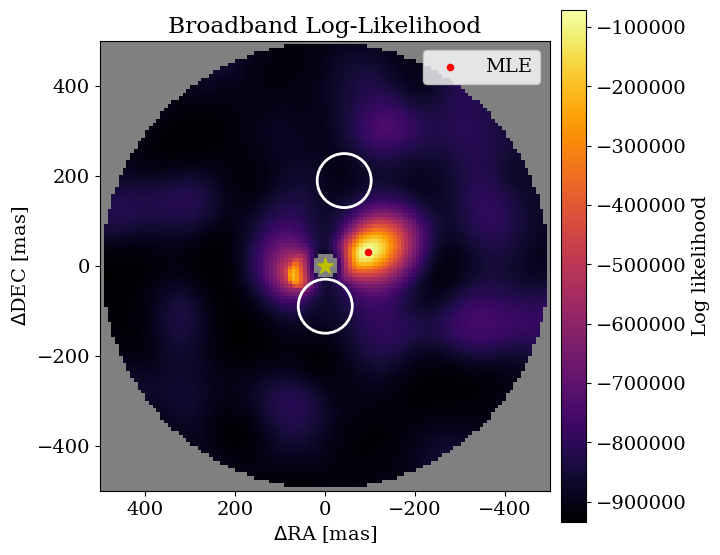

In [8]:
import dLux.utils as dlu
import matplotlib.patches as patches
from amigo.misc import tqdm

# # Values from here, Fig 16: 
# # https://www.stsci.edu/files/live/sites/www/files/home/jwst/documentation/_documents/jwst-science-performance-report.pdf
# pa, sep = -79.4, 325.6
# ra = sep * np.sin(dlu.deg2rad(pa))
# dec = sep * np.cos(dlu.deg2rad(pa))
binaries = [
    (-43, 189),  # Ra, Dec
    (-1, -90),  # Ra, Dec
]


# Samples
n = 120
size = 500 # mas
RAs = np.linspace(size, -size, n)
Decs = np.linspace(-size, size, n)
fluxes = np.linspace(-6, 0, n)
grid = {"dra": RAs, "ddec": Decs, "flux": 10 ** fluxes}


# Calculate the log-likelihoods
loglike_ims, contrast_ims, fovs = {}, {}, {}
for filt, oi_data in tqdm(cal_vis_outputs.items()):
    loglike_im, contrast_im, fov = fit_oi_data(
        grid, oi_data, 
        amp_scale=1,
        phi_scale=1,
        n_batch=500, 
    )
    loglike_ims[filt] = loglike_im
    contrast_ims[filt] = contrast_im
    fovs[filt] = fov

# Get the MLEs
loglike_im = np.array(jtu.leaves(loglike_ims)).sum(axis=0)
dec_ind, ra_ind = np.where(loglike_im == np.nanmax(loglike_im))
contrast_mles = jtu.map(lambda x: np.log10(x[*dec_ind, *ra_ind]), contrast_ims)
ra_mle, dec_mle = RAs[*ra_ind], Decs[*dec_ind]

# print("(RA, Dec)")
print(f"RA: {ra_mle:.2f}")
print(f"Dec: {dec_mle:.2f}")
[print(f"{filt}: {contrast:.2f}") for filt, contrast in contrast_mles.items()]


#
extent = (RAs[0], RAs[-1], Decs[0], Decs[-1])
make_circle = lambda position, diameter, **kwargs: patches.Circle(
    position, diameter / 2, color="w", fill=False, linewidth=2, **kwargs
)

plt.figure(figsize=(7, 7))
ax = plt.subplot(1, 1, 1)
plt.imshow(loglike_im, cmap=inferno, aspect="equal", extent=extent)
plt.colorbar(shrink=0.95, label="Log likelihood", pad=0.02)
plt.scatter(0, 0, s=140, c="y", marker="*")
ax.set(title="Broadband Log-Likelihood", xlabel="$\\Delta$RA [mas]", ylabel="$\\Delta$DEC [mas]",)
ax.scatter(ra_mle, dec_mle, s=80, c="r", marker=".", label="MLE")
[ax.add_patch(make_circle(binary, 120)) for binary in binaries]
# ax.add_patch(make_circle((0, 0), diff_lim, ls="--", label="Diffraction limit"))
ax.legend()
plt.show()
